In [87]:
#Construir Modelos de Aprendizado Maquina
#Entrega Fase Final 2
#Aluno: Helder de Oliveira Barros

#Importar BiBliotecas
import pandas as pd

import numpy as np

import joblib

import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [88]:
#Carregar Arquivo
df = pd.read_csv("dataImobiliarioSaoPaulo.csv")

df.head()

,address,district,area,bedrooms,garage,type,rent,total
0,Rua Herval,Belenzinho,21,1,0,Studio e kitnet,2400,2939
1,Avenida São Miguel,Vila Marieta,15,1,1,Studio e kitnet,1030,1345
2,Rua Oscar Freire,Pinheiros,18,1,0,Apartamento,4000,4661
3,Rua Júlio Sayago,Vila Ré,56,2,2,Casa em condomínio,1750,1954
4,Rua Barata Ribeiro,Bela Vista,19,1,0,Studio e kitnet,4000,4654


In [89]:
#Conhecimento de Dados
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11657 entries, 0 to 11656
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   address   11657 non-null  object
 1   district  11657 non-null  object
 2   area      11657 non-null  int64 
 3   bedrooms  11657 non-null  int64 
 4   garage    11657 non-null  int64 
 5   type      11657 non-null  object
 6   rent      11657 non-null  int64 
 7   total     11657 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 728.7+ KB


address     0
district    0
area        0
bedrooms    0
garage      0
type        0
rent        0
total       0
dtype: int64

In [90]:
#Limpar Dados
df = df.dropna()

In [91]:
#Separar variavel
X = df.drop("rent", axis=1)

y = df["rent"]

In [92]:
#Transformar Texto em Números
encoder = LabelEncoder()

for coluna in X.select_dtypes(include="object"):
    X[coluna] = encoder.fit_transform(X[coluna])

In [93]:
#Dividir Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [94]:
#Treinar Modelo
modelo = RandomForestRegressor(random_state=42)

modelo.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [95]:
#Previsões
y_pred = modelo.predict(X_test)

In [96]:
#Avaliar Métricas
mae = mean_absolute_error(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R²:",r2)

MAE: 222.8883061749571
MSE: 149606.36629918523
RMSE: 386.7898218660688
R²: 0.978825223595769


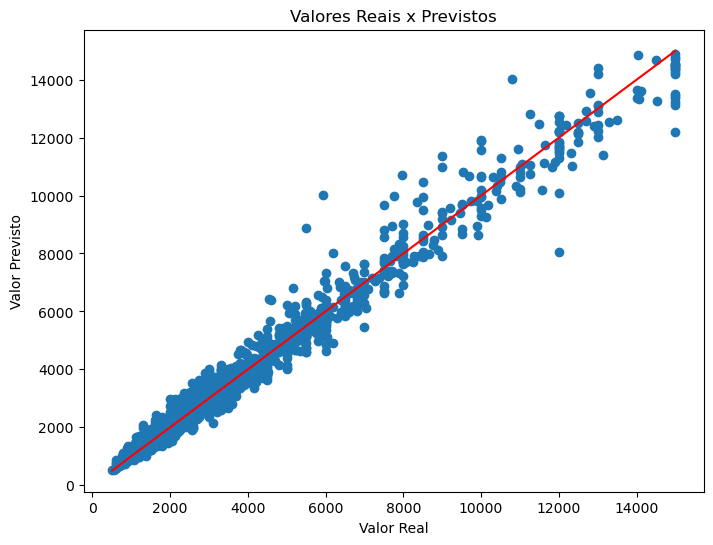

In [97]:
#Gráfico
plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color="red"
)

plt.xlabel("Valor Real")

plt.ylabel("Valor Previsto")

plt.title("Valores Reais x Previstos")

plt.show()

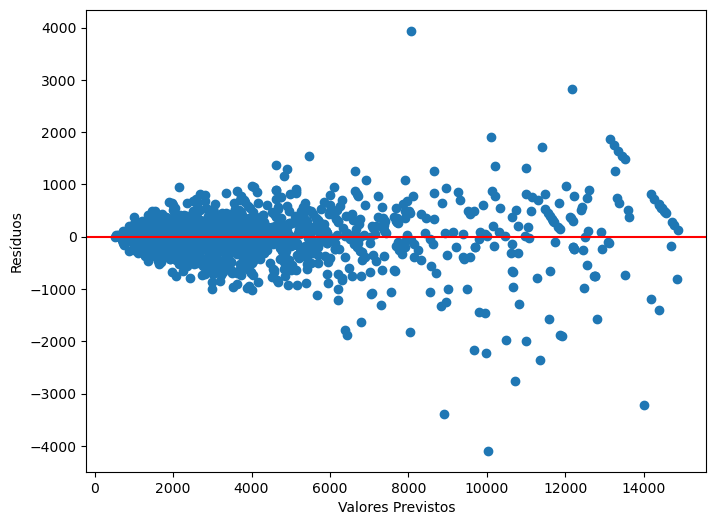

In [98]:
#Residuos
residuos = y_test-y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred,residuos)

plt.axhline(y=0,color="red")

plt.xlabel("Valores Previstos")

plt.ylabel("Resíduos")

plt.show()

In [99]:
#Otimizar Modelo
parametros = {

    "n_estimators":[100,200,300],

    "max_depth":[10,20,None],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2]

}

grid = GridSearchCV(

    RandomForestRegressor(random_state=42),

    parametros,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [100]:
#Melhor Modelo
grid.best_params_

{'max_depth': 10,
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 300}

In [101]:
#Melhor Desempenho
grid.best_score_

np.float64(0.979263606013354)

In [102]:
#Testar De Novo
modelo_final = grid.best_estimator_

y_pred = modelo_final.predict(X_test)

print(r2_score(y_test,y_pred))

0.9791538042210356


In [103]:
#Salvar Modelo
joblib.dump(modelo_final,"modelo_imoveis.pkl")


['modelo_imoveis.pkl']